#### Step 1: Import Required Libraries

In [346]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)


#### Step 2: Load the Dataset

In [347]:
column_names = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=column_names)
print("Shape:",df.shape)
df.head()


Shape: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#### Step 3: Encode Class Labels

* M → 1 (Malignant)

* B → 0 (Benign)

In [348]:
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

#### Step 4: Exploratory Data Analysis (EDA)

* Class Distribution

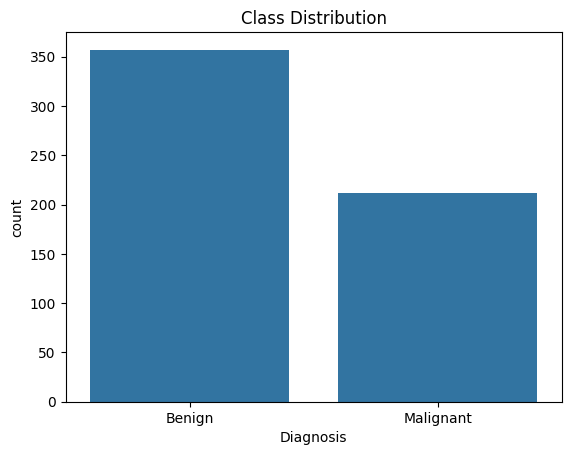

In [349]:
sns.countplot(x="Diagnosis", data = df)
plt.xticks([0,1], ["Benign", "Malignant"])
plt.title("Class Distribution")
plt.show()

* Feature Correlation

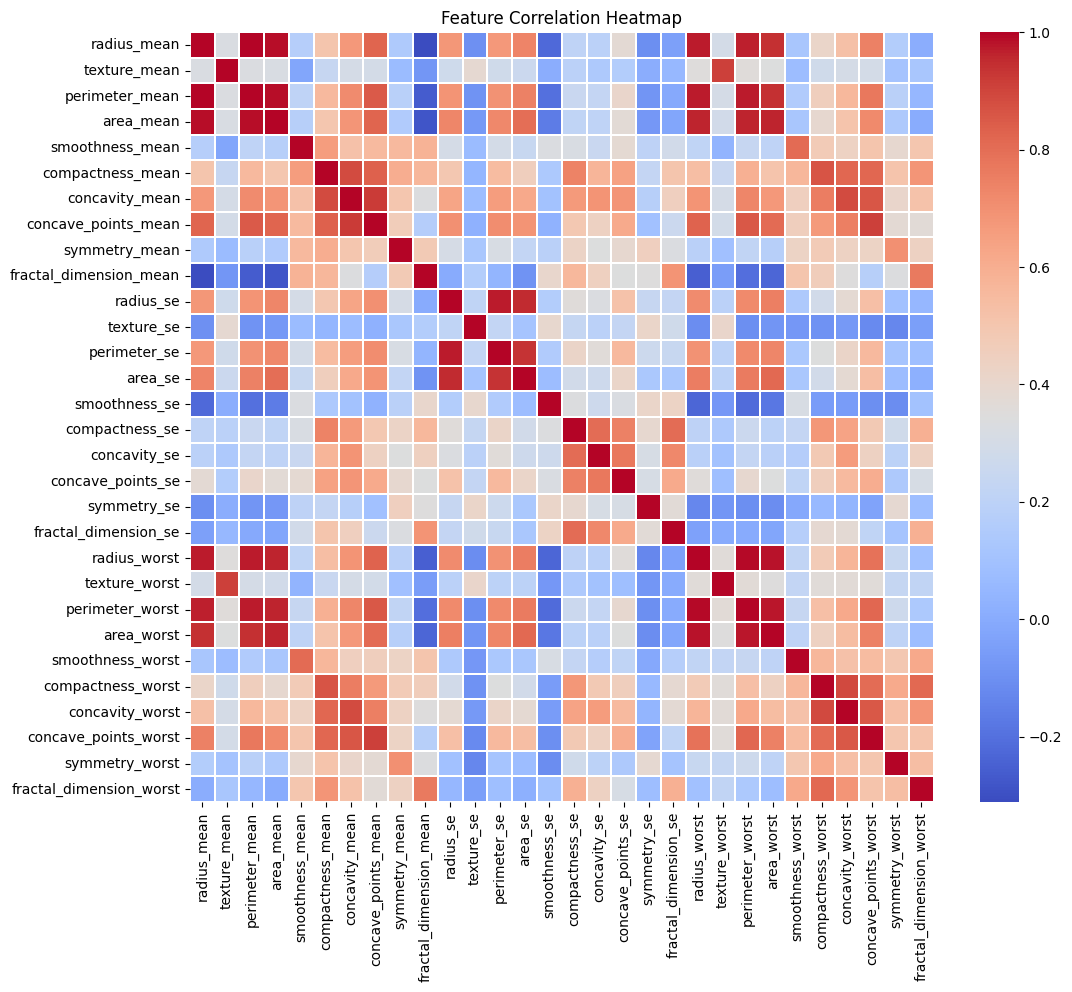

In [350]:
plt.figure(figsize=(12,10))
sns.heatmap(df.iloc[:, 2:].corr(), cmap="coolwarm", linewidth=0.01)
plt.title("Feature Correlation Heatmap")
plt.show()

#### Step 5: Split Features and Target

* Remove ID

* Separate X and y

In [351]:
X = df.drop(["ID", "Diagnosis"], axis=1)
y = df["Diagnosis"]

#### Step 6: Train–Test Split (80–20)

In [352]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training set: (455, 30)
Testing set: (114, 30)
Training labels: (455,)
Testing labels: (114,)


#### Step 7: Train a Decision Tree Classifier

In [353]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [354]:
accuracy_dt = accuracy_score(y_test,y_pred_dt)
print("Decision Tree Accuracy:",accuracy_dt)
print("Classification Report:\n",classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9298245614035088
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



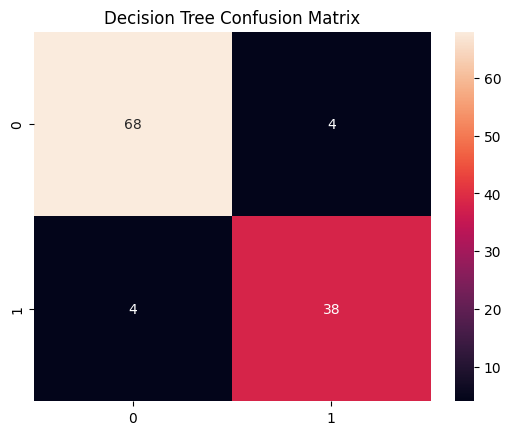

In [355]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True)
plt.title("Decision Tree Confusion Matrix")
plt.show()

#### Step 8: Decision Tree Hyperparameter Tuning (5-Fold CV)

In [356]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [357]:
print("Best Parameters:",dt_grid.best_params_)
print("Best CV Accuracy:",dt_grid.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV Accuracy: 0.9362637362637363


#### Step 9: Evaluate Decision Tree

In [358]:
best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)

acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", acc)

print("Decision Tree Performance")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9649122807017544
Decision Tree Performance
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



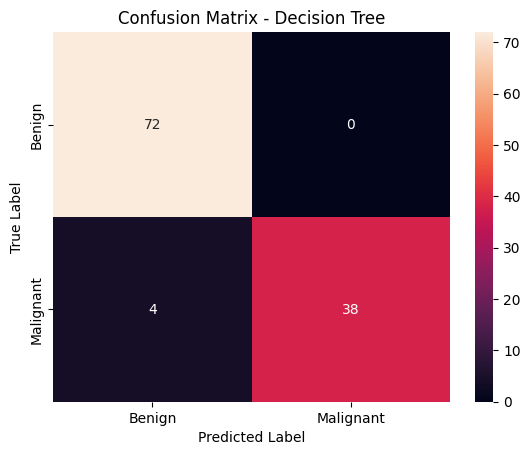

In [359]:
# Confusion matrix
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5,1.5], ["Benign", "Malignant"])
plt.yticks([0.5,1.5], ["Benign", "Malignant"])
plt.show()

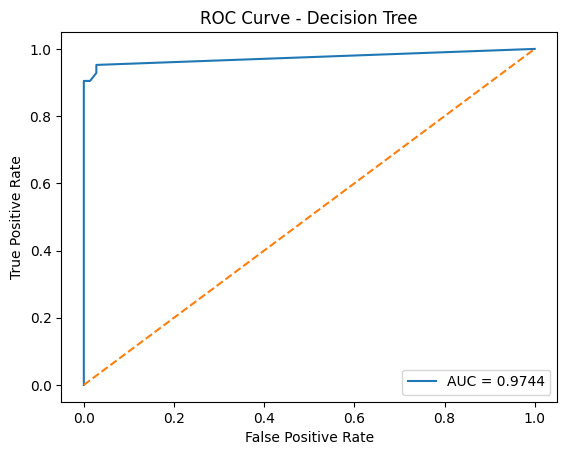

Decision Tree AUC: 0.9743716931216931


In [360]:
# Probability predictions
dt_probs = best_dt.predict_proba(X_test)[:, 1]

# Compute ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("Decision Tree AUC:", auc_dt)

In [361]:
dt_results = []

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7]
}

for criterion in dt_param_grid["criterion"]:
    for depth in dt_param_grid["max_depth"]:
        
        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth,
            random_state=42
        )
        
        scores = cross_validate(
            model, X_train, y_train,
            cv=cv,
            scoring=["accuracy", "f1"]
        )
        
        dt_results.append({
            "Criterion": criterion,
            "Max Depth": depth,
            "Avg CV Accuracy (%)": np.mean(scores["test_accuracy"]) * 100,
            "Avg CV F1 Score": np.mean(scores["test_f1"])
        })

dt_table = pd.DataFrame(dt_results)
dt_table

,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,gini,NaN,92.307692,0.896184
1,gini,3.0,92.087912,0.888437
2,gini,5.0,90.769231,0.871738
3,gini,7.0,92.307692,0.896184
4,entropy,NaN,91.868132,0.890865
5,entropy,3.0,92.527473,0.894103
6,entropy,5.0,92.307692,0.895159
7,entropy,7.0,91.648352,0.886155


#### Step 10: Train Random Forest Classifier

In [362]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:",accuracy_rf)

print("Classification report:\n",classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9736842105263158
Classification report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



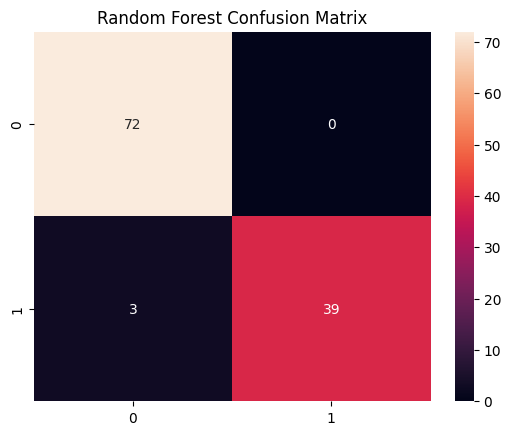

In [363]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

#### Step 11: Random Forest Hyperparameter Tuning (5-Fold CV)

In [364]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [365]:
print("Best Parameters:",rf_grid.best_params_)
print("Best CV Accuracy:",rf_grid.best_score_)

Best Parameters: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV Accuracy: 0.9670329670329672


#### Step 12: Evaluate Random Forest

In [366]:
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

print("Random Forest Performance")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9736842105263158
Random Forest Performance
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



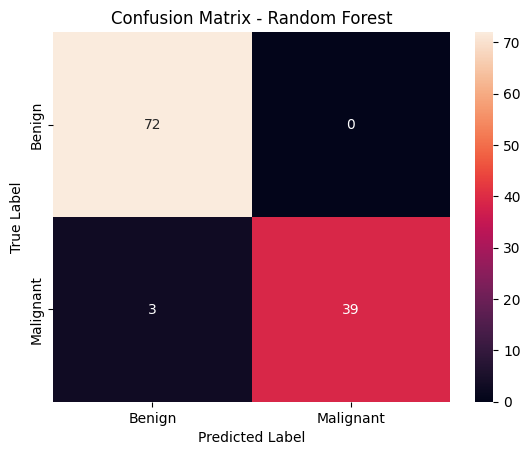

In [367]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5,1.5], ["Benign", "Malignant"])
plt.yticks([0.5,1.5], ["Benign", "Malignant"])
plt.show()

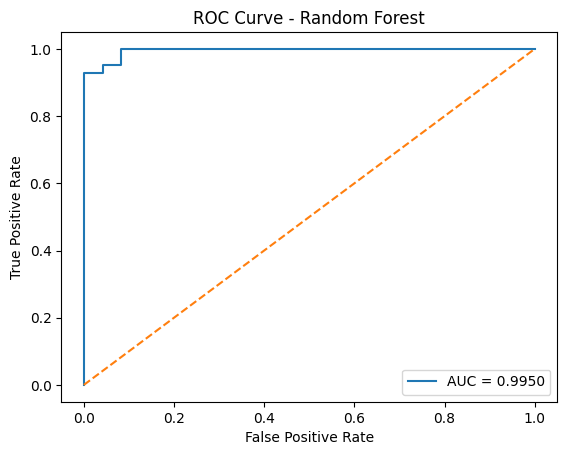

Random Forest AUC: 0.9950396825396824


In [368]:
# Probability predictions
rf_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("Random Forest AUC:", auc_rf)

In [369]:
rf_results = []

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

for n in rf_param_grid["n_estimators"]:
    for depth in rf_param_grid["max_depth"]:
        for feat in rf_param_grid["max_features"]:
            
            model = RandomForestClassifier(
                n_estimators=n,
                max_depth=depth,
                max_features=feat,
                random_state=42
            )
            
            scores = cross_validate(
                model, X_train, y_train,
                cv=cv,
                scoring=["accuracy", "f1"]
            )
            
            rf_results.append({
                "n_estimators": n,
                "Max Depth": depth,
                "Max Features": feat,
                "Avg CV Accuracy (%)": np.mean(scores["test_accuracy"]) * 100,
                "Avg CV F1 Score": np.mean(scores["test_f1"])
            })

rf_table = pd.DataFrame(rf_results)
rf_table

,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,100,NaN,sqrt,96.483516,0.951945
1,100,NaN,log2,96.483516,0.952927
2,100,5.0,sqrt,96.703297,0.955285
3,100,5.0,log2,96.043956,0.946498
4,100,10.0,sqrt,96.483516,0.951945
5,100,10.0,log2,96.483516,0.952927
6,200,NaN,sqrt,96.263736,0.948876
7,200,NaN,log2,96.483516,0.952554
8,200,5.0,sqrt,95.604396,0.940087
9,200,5.0,log2,96.043956,0.946148


#### Step 13: Compare Decision tree and Random Forest

In [370]:
# Get best row
best_dt_params = dt_table.loc[dt_table["Avg CV F1 Score"].idxmax()]

# Fix max_depth conversion
best_depth = best_dt_params["Max Depth"]

if pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

best_dt = DecisionTreeClassifier(
    criterion=best_dt_params["Criterion"],
    max_depth=best_depth,
    random_state=42
)



best_rf_params = rf_table.loc[rf_table["Avg CV F1 Score"].idxmax()]

best_rf_depth = best_rf_params["Max Depth"]

if pd.isna(best_rf_depth):
    best_rf_depth = None
else:
    best_rf_depth = int(best_rf_depth)

best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_params["n_estimators"]),
    max_depth=best_rf_depth,
    max_features=best_rf_params["Max Features"],
    random_state=42
)

In [371]:
dt_fold_scores = cross_validate(best_dt, X, y, cv=cv, scoring="accuracy")
rf_fold_scores = cross_validate(best_rf, X, y, cv=cv, scoring="accuracy")

comparison_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_fold_scores["test_score"][0]*100,
               rf_fold_scores["test_score"][0]*100],
    "Fold 2": [dt_fold_scores["test_score"][1]*100,
               rf_fold_scores["test_score"][1]*100],
    "Fold 3": [dt_fold_scores["test_score"][2]*100,
               rf_fold_scores["test_score"][2]*100],
    "Fold 4": [dt_fold_scores["test_score"][3]*100,
               rf_fold_scores["test_score"][3]*100],
    "Fold 5": [dt_fold_scores["test_score"][4]*100,
               rf_fold_scores["test_score"][4]*100],
    "Average": [
        np.mean(dt_fold_scores["test_score"]) * 100,
        np.mean(rf_fold_scores["test_score"]) * 100
    ]
})

comparison_table

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,92.982456,86.842105,88.596491,93.859649,92.920354,91.040211
1,Random Forest,96.491228,93.859649,96.491228,96.491228,96.460177,95.958702


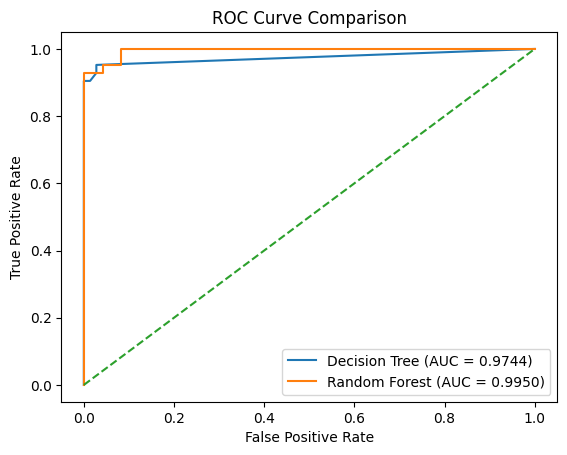

In [372]:
plt.figure()

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()